<a href="https://colab.research.google.com/github/truongbao11092006-NA/hoc-git-co-ban/blob/main/exercise_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
print('hello')

hello


In [11]:
import numpy as np
from google.colab.patches import cv2_imshow
import cv2

In [12]:
import matplotlib.pyplot as plt

In [13]:
from google.colab import drive
# drive.mount('/content/drive')

(408, 612)


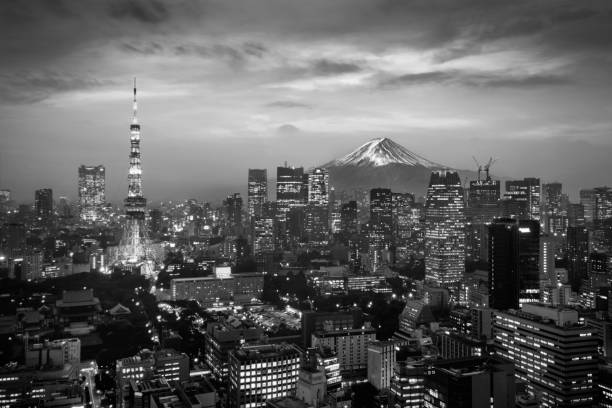

In [14]:
gray_img = cv2.imread('/NewBackground.jpg',0)
print(gray_img.shape)
cv2_imshow(gray_img)

### bai 4

In [15]:
original_background_img = cv2.imread('/GreenBackground.png',1)
object_img = cv2.imread('/Object.png',1)
target_background_img = cv2.imread('/NewBackground.jpg',1)
print(original_background_img.shape,object_img.shape,target_background_img.shape)

(381, 678, 3) (381, 678, 3) (408, 612, 3)


(381, 678, 3) (381, 678, 3) (381, 678, 3)


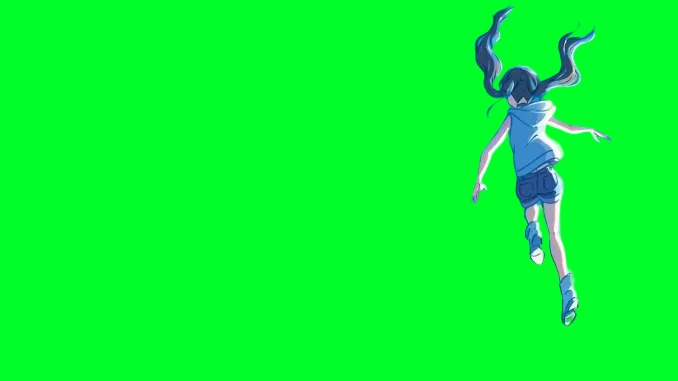

In [34]:
img_size = (678,381)#w,h
original_background_resize_img = cv2.resize(original_background_img,img_size)
object_resize_img = cv2.resize(object_img,img_size)
target_background_resize_img =cv2.resize(target_background_img,img_size)
print(original_background_resize_img.shape,object_resize_img.shape,target_background_resize_img.shape)
cv2_imshow(object_resize_img)

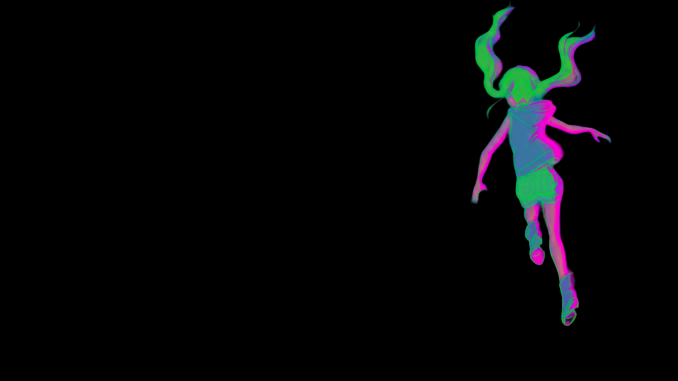

(381, 678, 3)
<class 'numpy.float64'>
<class 'numpy.uint8'>


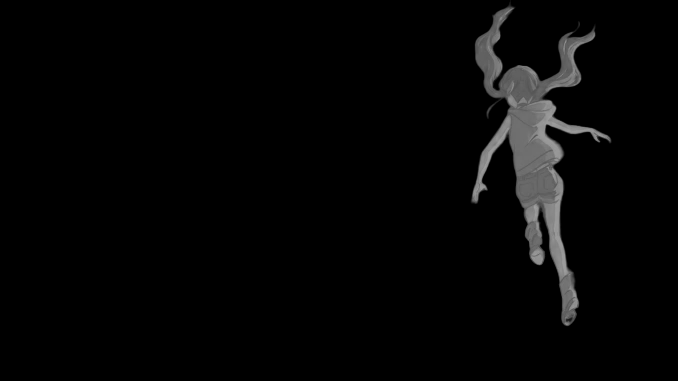

(381, 678)


In [32]:
differences = cv2.absdiff(original_background_resize_img,object_resize_img)
cv2_imshow(differences)
print(differences.shape)
differences_single = np.sum(differences,axis=2)/3.0
print(type(differences_single[0][0]))
differences_single = differences_single.astype(np.uint8)
print(type(differences_single[0][0]))
cv2_imshow(differences_single)
print(differences_single.shape)

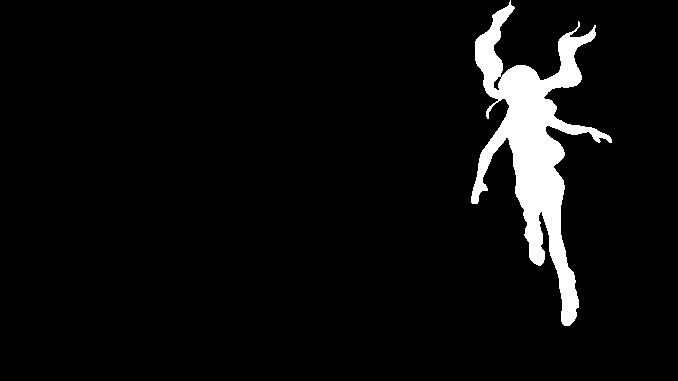

(381, 678, 3)


In [35]:
binary_img = np.where(differences_single>=10,255,0)
binary_img = np.stack((binary_img,)*3,axis=-1)
cv2_imshow(binary_img)
print(binary_img.shape)

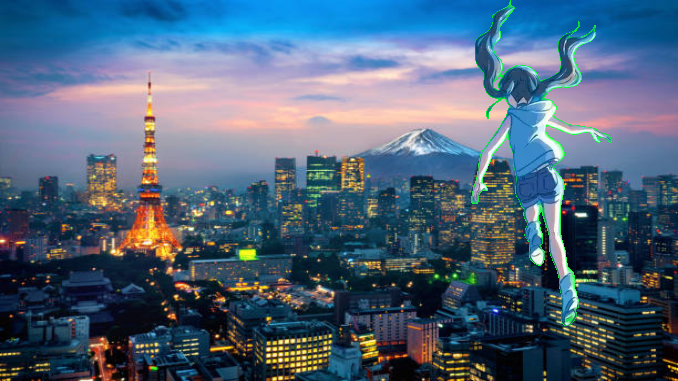

In [36]:
output = np.where(binary_img ==255, object_resize_img,target_background_resize_img)
cv2_imshow(output)